https://www.geeksforgeeks.org/ordinary-least-squares-ols-using-statsmodels/
https://python.quantecon.org/ols.html

In [3]:
##source:https://matheusfacure.github.io/python-causality-handbook/08-Instrumental-Variables.html

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
import statsmodels.formula.api as smf
import graphviz as gr

import seaborn as sns

import matplotlib.pyplot as plt
!pip install linearmodels
from linearmodels import IV2SLS

In [4]:
data = pd.read_csv("Book1.csv")
data.head()

,gender,age,Covid19cases,season
0,1,1,1,5
1,1,2,1,5
2,0,2,1,5
3,1,3,1,5
4,0,4,1,5


In [5]:
data = data.assign(**{f"s{int(s)}": (data["season"] == s).astype(int)
                             for s in data["season"].unique()})

data.head()

,gender,age,Covid19cases,season,s5,s9,s1
0,1,1,1,5,1,0,0
1,1,2,1,5,1,0,0
2,0,2,1,5,1,0,0
3,1,3,1,5,1,0,0
4,0,4,1,5,1,0,0


In [6]:
x = data[['age','gender','s5', 's9']]

y = data['Covid19cases']

## IV is data under the column 'season' -> z = data[['s5','s9','s1']]

In [7]:
regression = LinearRegression()

regression.fit(x, y)
print('Intercept: \n', regression.intercept_)

print('Coefficients: \n', regression.coef_)

Intercept: 
 7.71930431530226
Coefficients: 
 [ 0.01023891  0.74484548 -6.74044602 -3.64181589]


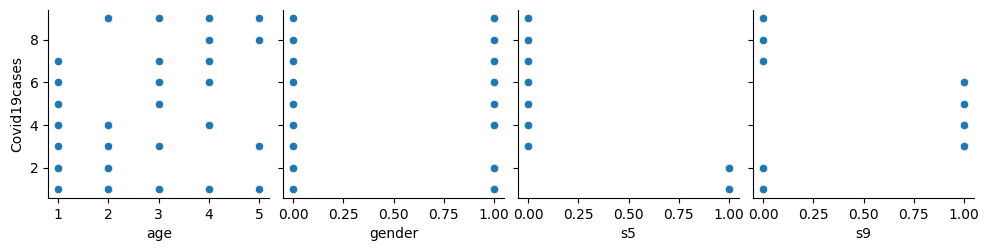

In [8]:
sns.pairplot(data,x_vars=['age','gender','s5','s9'],y_vars=['Covid19cases'])

Original Linear regression model of predicting Covid19cases based on gender and age. Assessing the importance of the AGE variable

In [9]:
result1 = smf.ols("Covid19cases ~1  + C(gender) + age", data=data).fit()

print("age parameter estimate:, ", result1.params["age"])
print("age p-value:, ", result1.pvalues["age"])

age parameter estimate:,  0.5969696969696969
age p-value:,  0.0842388540982715


In [10]:
print(result1.summary())

                            OLS Regression Results                            
Dep. Variable:           Covid19cases   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.178
Date:                Thu, 13 Feb 2025   Prob (F-statistic):              0.128
Time:                        19:06:52   Log-Likelihood:                -95.419
No. Observations:                  40   AIC:                             196.8
Df Residuals:                      37   BIC:                             201.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.0785      1.123      1.

Original Linear regression model of predicting Covid19cases based on gender and age. Assessing the importance of the GENDER variable

In [11]:
result2 = smf.ols("Covid19cases ~ C(age)+ gender", data=data).fit()

print("gender parameter estimate:, ", result2.params["gender"])
print("gender p-value:, ", result2.pvalues["gender"])

gender parameter estimate:,  1.115332525482928
gender p-value:,  0.244671590943241


In [12]:
print(result2.summary())

                            OLS Regression Results                            
Dep. Variable:           Covid19cases   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.8428
Date:                Thu, 13 Feb 2025   Prob (F-statistic):              0.529
Time:                        19:07:01   Log-Likelihood:                -95.308
No. Observations:                  40   AIC:                             202.6
Df Residuals:                      34   BIC:                             212.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.8193      1.115      2.528      

Original Linear regression model of predicting Covid19cases based on gender,  age and the product of age * gender. Assessing the importance of the age * gender variable

In [13]:
result3 = smf.ols("Covid19cases ~ C(age)+ C(gender) + C(age)*(gender)", data=data).fit()

print(result3.summary())


                            OLS Regression Results                            
Dep. Variable:           Covid19cases   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     1.645
Date:                Thu, 13 Feb 2025   Prob (F-statistic):              0.147
Time:                        19:07:05   Log-Likelihood:                -89.623
No. Observations:                  40   AIC:                             199.2
Df Residuals:                      30   BIC:                             216.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.6667      1

Original Linear regression model of predicting Covid19cases based on gender, age and seasonal variable that represents the fall cases. Assessing the importance of the season - fall variable.

In [14]:
mean_age = np.mean(data['age'])
mean_age

2.6

Predicting number of Covid19 Cases for male

In [15]:
predicted_Covid19cases = 2.81 + 1.11 * 1
predicted_Covid19cases

3.92

In [28]:
X = data[['age', 'gender', 's5']]  # Dropping 's9' and 's1' to avoid multicollinearity
y = data['Covid19cases']

# Apply the IV2SLS model
res_ols = IV2SLS(y, X, None, None).fit(cov_type='unadjusted')
print(res_ols)

                            OLS Estimation Summary                            
Dep. Variable:           Covid19cases   R-squared:                      0.8124
Estimator:                        OLS   Adj. R-squared:                 0.7972
No. Observations:                  40   F-statistic:                    173.18
Date:                Thu, Feb 13 2025   P-value (F-stat)                0.0000
Time:                        19:21:46   Distribution:                  chi2(3)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
age            1.3471     0.1543     8.7321     0.0000      1.0447      1.6494
gender         2.7512     0.6227     4.4184     0.00

R-squared (0.8124): This indicates that approximately 81.24% of the variance in Covid19cases is explained by the model, suggesting a good fit.

Adjusted R-squared (0.7972): Slightly lower than the R-squared, which is expected, but still indicates a strong model fit.

Coefficients:
age (1.3471): For each additional year of age, the number of Covid19 cases increases by approximately 1.35, holding other variables constant. This effect is statistically significant (p-value = 0.0000).
gender (2.7512): Being of a certain gender (assuming 1 for male and 0 for female) increases the number of Covid19 cases by approximately 2.75, holding other variables constant. This effect is also statistically significant (p-value = 0.0000).
s5 (-3.2105): The coefficient for s5 (which stands for Summer) is negative, indicating that this season is associated with a decrease in Covid19 cases by approximately 3.21 (which is logical, since there are fewer respiratory diseases in the summer), holding other variables constant. This effect is statistically significant (p-value = 0.0000).

In [29]:
result4 = smf.ols("Covid19cases ~ C(gender) + C(age) + s9", data=data).fit()

print("s9 parameter estimate:, ", result4.params["s9"])
print("s9 p-value:, ", result4.pvalues["s9"])

##high p-value 0.52,failing to reject the null hypothesis. The coefficient is also smaller compared
## to the coefficients of the other 2 seasons. Has no significant effect.

s9 parameter estimate:,  0.6303935995669889
s9 p-value:,  0.5278825643367773


Original Linear regression model of predicting Covid19cases based on gender, age and seasonal variable that represents the summer cases. Assessing the importance of the season - summer variable.

In [30]:
result5 = smf.ols("Covid19cases ~ C(gender) + C(age) + s5", data=data).fit()

print("s5 parameter estimate:, ", result5.params["s5"])
print("s5 p-value:, ", result5.pvalues["s5"])

##very small p-value 0.0000000003, it's a rejection of the null hypothesis
## The coefficient of S5 is significant

s5 parameter estimate:,  -4.5487615406515705
s5 p-value:,  3.1779949999417082e-09


Original Linear regression model of predicting Covid19cases based on gender, age and seasonal variable that represents the winter cases. Assessing the importance of the season - winter variable.

In [18]:
result6 = smf.ols("Covid19cases ~ C(gender) + C(age) + s1", data=data).fit()

print("s1 parameter estimate:, ", result6.params["s1"])
print("s1 p-value:, ", result6.pvalues["s1"])

## very small p-value 0.0000000002, it's a rejection of the null hypothesis. The coefficient of S1 - winter
## is equal to 5.27 and it is statistically significant. there is 5.27 points higher chance of getting Covid
## in the winter season, which is also intuitively correct.

s1 parameter estimate:,  5.275932638820853
s1 p-value:,  2.6775947718875947e-09


Instrumental variables analyss. Regressing gender on the season.
Interpretation ???

In [32]:
resultIV1 = smf.ols("gender~ s1", data=data).fit()

print("s1 parameter estimate:, ", resultIV1.params["s1"])
print("s1 p-value:, ", resultIV1.pvalues["s1"])

s1 parameter estimate:,  0.13333333333333353
s1 p-value:,  0.478003216334857


In [33]:
resultIV2 = smf.ols("gender~ s5", data=data).fit()

print("s5 parameter estimate:, ", resultIV2.params["s5"])
print("s5 p-value:, ", resultIV2.pvalues["s5"])

s5 parameter estimate:,  0.05333333333333344
s5 p-value:,  0.7516583776443804


In [34]:
resultIV3 = smf.ols("gender~ s9", data=data).fit()

print("s9 parameter estimate:, ", resultIV3.params["s9"])
print("s9 p-value:, ", resultIV3.pvalues["s9"])

s9 parameter estimate:,  -0.15999999999999978
s9 p-value:,  0.3398276290656145


In [37]:
##2sls

formula = 'Covid19cases ~ 1 + age + [gender ~ s1+s5]'
ols2 = IV2SLS.from_formula(formula, data).fit()
print(ols2.summary)

# negative values of R-squared and Ajd. R-squared indicate a weak fit of the model.

                          IV-2SLS Estimation Summary                          
Dep. Variable:           Covid19cases   R-squared:                     -3.0070
Estimator:                    IV-2SLS   Adj. R-squared:                -3.2235
No. Observations:                  40   F-statistic:                    2.6887
Date:                Thu, Feb 13 2025   P-value (F-stat)                0.2607
Time:                        19:28:16   Distribution:                  chi2(2)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -4.4105     5.8492    -0.7540     0.4508     -15.875      7.0536
age            1.1842     0.7358     1.6094     0.10